In [18]:
!pip install kaggle
!pip install -U tensorflow

In [19]:
from google.colab import files
files.upload()

Saving busuk_buah-300x227.jpg to busuk_buah-300x227 (1).jpg


{'busuk_buah-300x227 (1).jpg': b'\xff\xd8\xff\xe1\x00\x02\xff\xe1\x00\x02\xff\xdb\x00\x84\x00\x06\x04\x04\x05\x04\x04\x06\x05\x05\x05\x06\x06\x06\x07\t\x0e\t\t\x08\x08\t\x12\r\r\n\x0e\x15\x12\x16\x16\x15\x12\x14\x14\x17\x1a!\x1c\x17\x18\x1f\x19\x14\x14\x1d\'\x1d\x1f"#%%%\x16\x1c),($+!$%$\x01\x06\x06\x06\t\x08\t\x11\t\t\x11$\x18\x14\x18$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$\xff\xc2\x00\x11\x08\x00\xe3\x01,\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x006\x00\x00\x02\x02\x03\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x05\x06\x00\x04\x03\x07\x08\x02\x01\t\x01\x00\x02\x03\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x03\x04\x00\x01\x02\x05\x06\x07\xff\xda\x00\x0c\x03\x01\x00\x02\x10\x03\x10\x00\x00\x00\xea\x88\xab\xa2\x05\xae\xa1\x9c\x84\xc2:\xe9\xc9\xcc\xf8k}=9z\xc6u\xd33\x92\xd6\xb7;f~u\x028\xff\x00L\xa7\x01l\xac\xdfY\xceK\x07/\xb4\':\xa9\x8b\x1dm9\x14<\x9d\xa595\x08\xbb\xee\xf9\xcc$\xc5\x8e\x8b\x9a\x02]o\xf9\xc9$\xae\xfa\x92rb\xee\xa7j\xceF\xc6=u\xec\xe3\xb3\xb2

In [20]:
#before importing the dataset we want to use this code
# The Kaggle API client expects this file to be in ~/.kaggle,
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

# This permissions change avoids a warning on Kaggle tool startup.
!chmod 600 ~/.kaggle/kaggle.json

In [21]:
!kaggle datasets download -d emmarex/plantdisease

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
 96% 634M/658M [00:03<00:00, 106MB/s] 
100% 658M/658M [00:03<00:00, 187MB/s]


In [22]:
!unzip "/content/plantdisease.zip" -d "/content/plantdisease"

Output streaming akan dipotong hingga 5000 baris terakhir.
  inflating: /content/plantdisease/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08c033bd-fbc3-445a-88d1-1863070e52ce___YLCV_GCREC 2872.JPG  
  inflating: /content/plantdisease/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08dd176c-e9d9-4746-92c3-fa8dc9074347___UF.GRC_YLCV_Lab 03057.JPG  
  inflating: /content/plantdisease/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08f78a80-46f5-45a6-937c-4d05d61c08c2___UF.GRC_YLCV_Lab 01895.JPG  
  inflating: /content/plantdisease/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0903aa95-6e8a-4abd-a003-126fcd9a5493___YLCV_GCREC 2806.JPG  
  inflating: /content/plantdisease/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0911d416-d73d-4c2a-8e45-207a7ceb7c9a___YLCV_GCREC 2773.JPG  
  inflating: /content/plantdisease/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/09188838-cc89-4925-94c5-d9563c

In [23]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
    #for filename in filenames:
       # print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import cv2
import os
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Flatten, Conv2D, MaxPool2D,
    BatchNormalization, AveragePooling2D, GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import DenseNet121

In [25]:
disease_types = ['Pepper__bell___Bacterial_spot','Pepper__bell___healthy','Potato___Early_blight','Potato___Late_blight','Potato___healthy','Tomato_Bacterial_spot','Tomato_Early_blight','Tomato_Late_blight','Tomato_Leaf_Mold','Tomato_Septoria_leaf_spot','Tomato_Spider_mites_Two_spotted_spider_mite','Tomato__Target_Spot','Tomato__Tomato_YellowLeaf__Curl_Virus','Tomato__Tomato_mosaic_virus','Tomato_healthy']
data_dir = '/content/plantdisease/PlantVillage/'
train_dir = os.path.join(data_dir)
#test_dir = os.path.join(data_dir, 'test')

In [26]:
train_data = []
for defects_id, sp in enumerate(disease_types):
    for file in os.listdir(os.path.join(train_dir, sp)):
        train_data.append(['{}/{}'.format(sp, file), defects_id, sp])

train = pd.DataFrame(train_data, columns=['File', 'DiseaseID','Disease Type'])
train.tail()

,File,DiseaseID,Disease Type
20634,Tomato_healthy/83781ea3-eaed-467a-9147-6780022...,14,Tomato_healthy
20635,Tomato_healthy/66534b5a-a6b7-46bb-bc09-a6bba9d...,14,Tomato_healthy
20636,Tomato_healthy/9e2a71e5-2a59-4e62-9c6c-581fe90...,14,Tomato_healthy
20637,Tomato_healthy/d673db62-484e-49d3-baca-0ffc0d2...,14,Tomato_healthy
20638,Tomato_healthy/b923ed54-63ad-49f8-8881-ebd654c...,14,Tomato_healthy


from matplotlib import pyplot as plt
import seaborn as sns
_df_0.groupby('File').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['DiseaseID']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'DiseaseID'}, axis=1)
              .sort_values('DiseaseID', ascending=True))
  xs = counted['DiseaseID']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_1.sort_values('DiseaseID', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('File')):
  _plot_series(series, series_name, i)
  fig.legend(title='File', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('DiseaseID')
_ = plt.ylabel('count()')

In [27]:
# Randomize the order of training set
SEED = 42
train = train.sample(frac=1, random_state=SEED)
train.index = np.arange(len(train)) # Reset indices
train.head()

,File,DiseaseID,Disease Type
0,Tomato_healthy/9630e186-4b6c-492b-b450-a30bd7f...,14,Tomato_healthy
1,Potato___Early_blight/41cc6e70-9745-413d-b13d-...,2,Potato___Early_blight
2,Tomato_Septoria_leaf_spot/3931a2cf-5122-47f2-b...,9,Tomato_Septoria_leaf_spot
3,Tomato_healthy/12a3a4c8-0f82-419c-9a7f-0fc6d26...,14,Tomato_healthy
4,Tomato_Leaf_Mold/b38caab5-9031-4877-ba93-96bec...,8,Tomato_Leaf_Mold


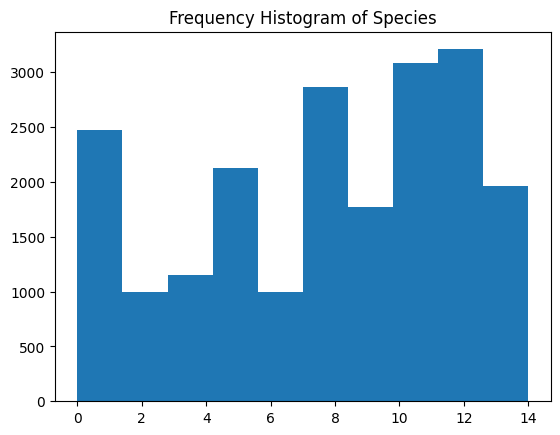

<Figure size 1200x1200 with 0 Axes>

In [28]:
# Plot a histogram
plt.hist(train['DiseaseID'])
plt.title('Frequency Histogram of Species')
plt.figure(figsize=(12, 12))
plt.show()

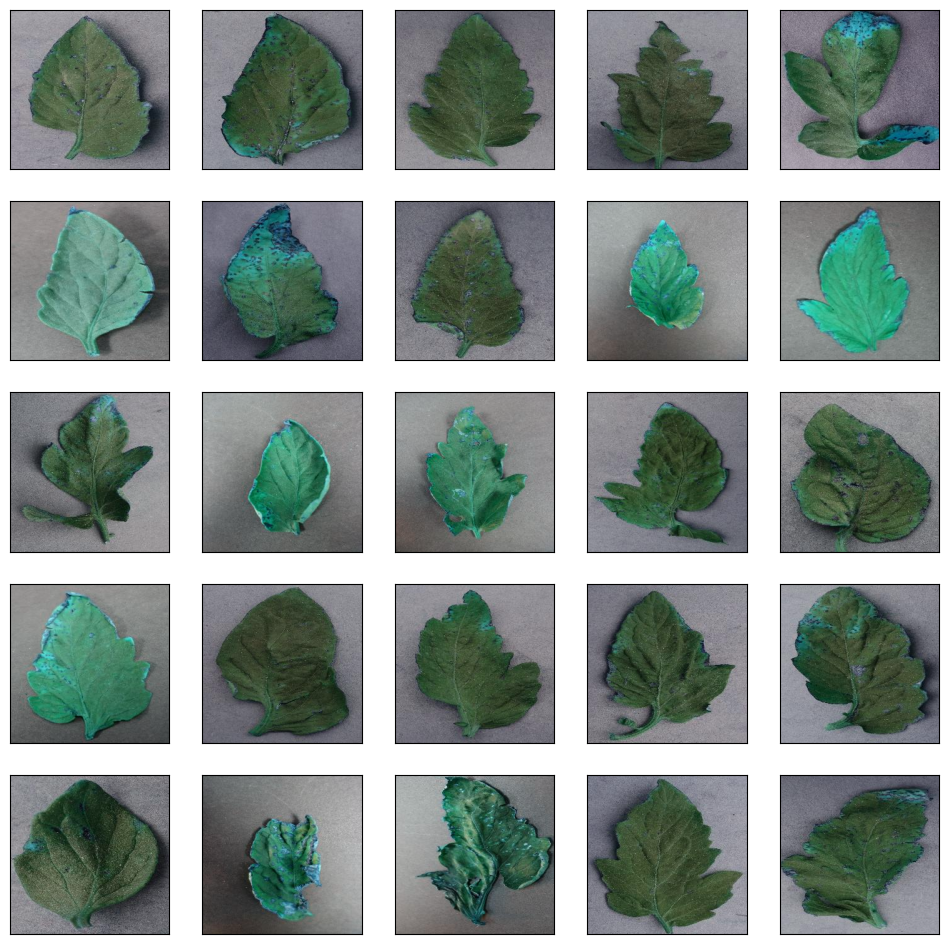

In [29]:
# Display images for different species
def plot_defects(defect_types, rows, cols):
    fig, ax = plt.subplots(rows, cols, figsize=(12, 12))
    defect_files = train['File'][train['Disease Type'] == defect_types].values
    n = 0
    for i in range(rows):
        for j in range(cols):
            image_path = os.path.join(data_dir, defect_files[n])
            ax[i, j].set_xticks([])
            ax[i, j].set_yticks([])
            ax[i, j].imshow(cv2.imread(image_path))
            n += 1
# Displays first n images of class from training set
plot_defects('Tomato_Bacterial_spot', 5, 5)

In [30]:
IMAGE_SIZE = 64

def read_image(filepath):
    return cv2.imread(os.path.join(data_dir, filepath)) # Loading a color image is the default flag
# Resize image to target size
def resize_image(image, image_size):
    return cv2.resize(image.copy(), image_size, interpolation=cv2.INTER_AREA)

In [31]:
X_train = np.zeros((train.shape[0], IMAGE_SIZE, IMAGE_SIZE, 3))
for i, file in tqdm(enumerate(train['File'].values)):
    image = read_image(file)
    if image is not None:
        X_train[i] = resize_image(image, (IMAGE_SIZE, IMAGE_SIZE))
# Normalize the data
X_Train = X_train / 255.
print('Train Shape: {}'.format(X_Train.shape))

20639it [00:14, 1403.47it/s]


Train Shape: (20639, 64, 64, 3)


In [32]:
Y_train = train['DiseaseID'].values
Y_train = to_categorical(Y_train, num_classes=15)

In [33]:
BATCH_SIZE = 64

# Split the train and validation sets
X_train, X_val, Y_train, Y_val = train_test_split(X_Train, Y_train, test_size=0.2, random_state=SEED)

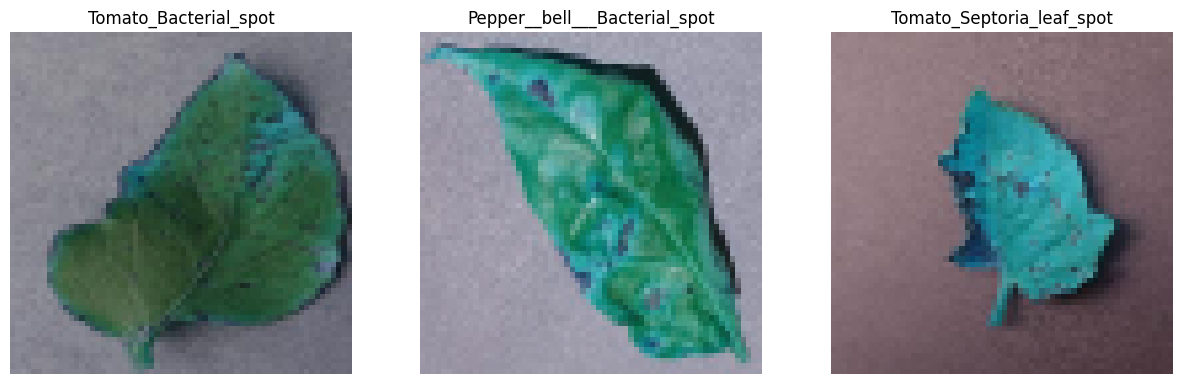

In [34]:
fig, ax = plt.subplots(1, 3, figsize=(15, 15))
for i in range(3):
    ax[i].set_axis_off()
    ax[i].imshow(X_train[i])
    ax[i].set_title(disease_types[np.argmax(Y_train[i])])

In [35]:
EPOCHS = 200
SIZE=64
N_ch=3

In [41]:
def build_densenet():
    densenet = DenseNet121(weights='imagenet', include_top=False)

    input = Input(shape=(SIZE, SIZE, N_ch))
    x = Conv2D(3, (3, 3), padding='same')(input)

    x = densenet(x)

    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    # multi output
    output = Dense(15,activation = 'softmax', name='root')(x)


    # model
    model = Model(input,output)

    optimizer = Adam(learning_rate=0.002, beta_1=0.9, beta_2=0.999, epsilon=0.1, decay=0.0)
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    model.summary()

    return model

In [44]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy',
                                            patience=2,
                                            verbose=1,
                                            factor=0.5,
                                            min_lr=1e-6)

In [45]:
model = build_densenet()
annealer = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=5, verbose=1, min_lr=1e-3)
checkpoint = ModelCheckpoint('model.h5', verbose=1, save_best_only=True)
# Generates batches of image data with data augmentation
datagen = ImageDataGenerator(rotation_range=360, # Degree range for random rotations
                        width_shift_range=0.2, # Range for random horizontal shifts
                        height_shift_range=0.2, # Range for random vertical shifts
                        zoom_range=0.2, # Range for random zoom
                        horizontal_flip=True, # Randomly flip inputs horizontally
                        vertical_flip=True) # Randomly flip inputs vertically

datagen.fit(X_train)
# Fits the model on batches with real-time data augmentation
hist = model.fit(datagen.flow(X_train, Y_train, batch_size=BATCH_SIZE),
                 steps_per_epoch=X_train.shape[0] // BATCH_SIZE,
                 epochs=EPOCHS,
                 validation_data=(X_val, Y_val),
                 callbacks=[learning_rate_reduction])

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 3)      │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 2, 2, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ root (Dense)                    │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,308,963 (27.88 MB)

 Trainable params: 7,222,755 (27.55 MB)

 Non-trainable params: 86,208 (336.75 KB)

Epoch 1/200


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


257/257 ━━━━━━━━━━━━━━━━━━━━ 317s 600ms/step - accuracy: 0.1759 - loss: 3.3191 - val_accuracy: 0.4031 - val_loss: 3.2575 - learning_rate: 0.0020
Epoch 2/200
  1/257 ━━━━━━━━━━━━━━━━━━━━ 33s 130ms/step - accuracy: 0.5000 - loss: 1.3550

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


257/257 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5000 - loss: 1.3550 - val_accuracy: 0.3939 - val_loss: 3.5111 - learning_rate: 0.0020
Epoch 3/200
257/257 ━━━━━━━━━━━━━━━━━━━━ 30s 117ms/step - accuracy: 0.5995 - loss: 1.3098 - val_accuracy: 0.6948 - val_loss: 1.0001 - learning_rate: 0.0020
Epoch 4/200
257/257 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7188 - loss: 0.9467 - val_accuracy: 0.7081 - val_loss: 0.9251 - learning_rate: 0.0020
Epoch 5/200
257/257 ━━━━━━━━━━━━━━━━━━━━ 30s 117ms/step - accuracy: 0.7543 - loss: 0.7673 - val_accuracy: 0.7030 - val_loss: 0.9643 - learning_rate: 0.0020
Epoch 6/200
257/257 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8125 - loss: 0.5412 - val_accuracy: 0.7154 - val_loss: 0.9277 - learning_rate: 0.0020
Epoch 7/200
257/257 ━━━━━━━━━━━━━━━━━━━━ 31s 121ms/step - accuracy: 0.8331 - loss: 0.5137 - val_accuracy: 0.7250 - val_loss: 1.0067 - learning_rate: 0.0020
Epoch 8/200
257/257 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8594 - loss: 0.5

In [46]:
#model = load_model('../output/kaggle/working/model.h5')
final_loss, final_accuracy = model.evaluate(X_val, Y_val)
print('Final Loss: {}, Final Accuracy: {}'.format(final_loss, final_accuracy))

129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9269 - loss: 0.1983
Final Loss: 0.1813439279794693, Final Accuracy: 0.9370155334472656


129/129 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step


Text(0.5, 192.58159722222217, 'Predicted')

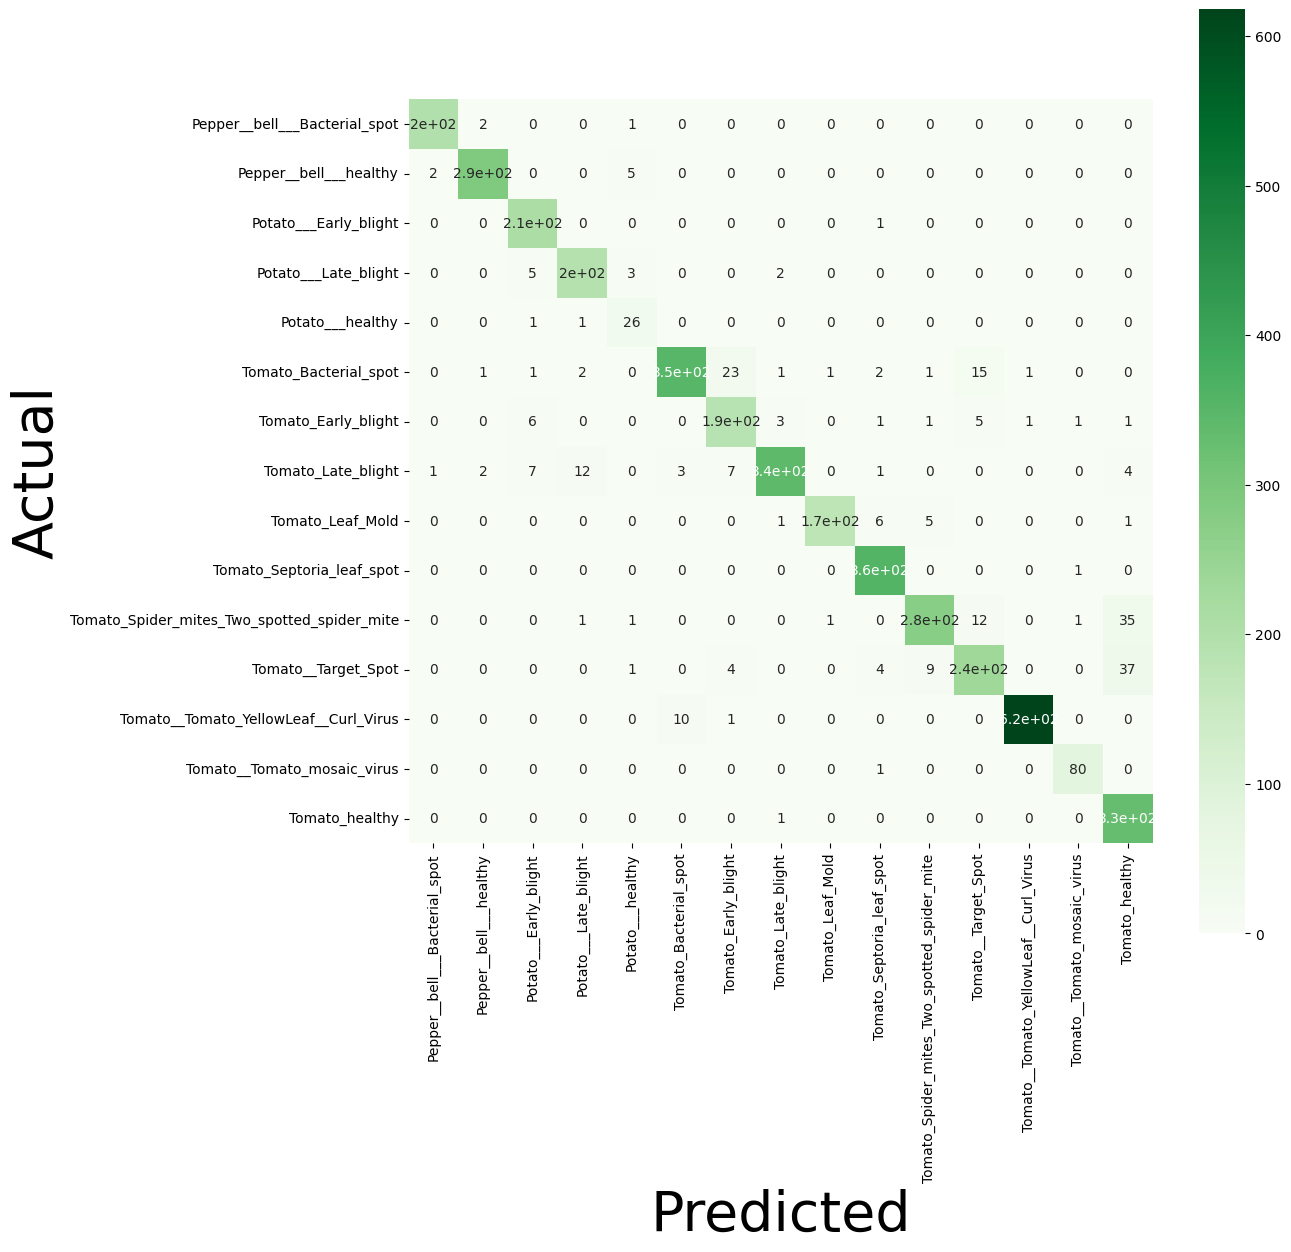

In [47]:
Y_pred = model.predict(X_val)

Y_pred = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(Y_val, axis=1)

cm = confusion_matrix(Y_true, Y_pred)
plt.figure(figsize=(12, 12))
ax = sns.heatmap(cm, cmap=plt.cm.Greens, annot=True, square=True, xticklabels=disease_types, yticklabels=disease_types)
ax.set_ylabel('Actual', fontsize=40)
ax.set_xlabel('Predicted', fontsize=40)

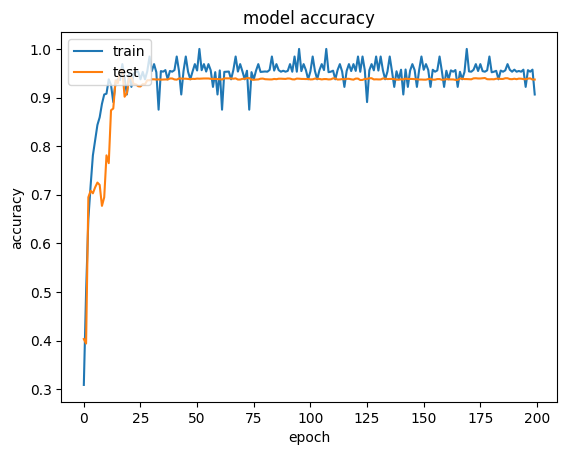

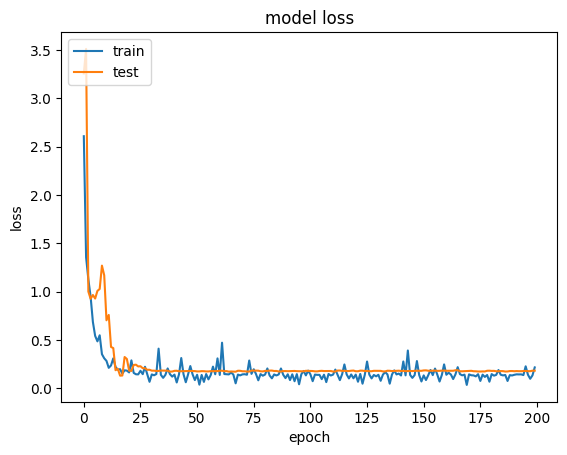

In [48]:
# accuracy plot
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# loss plot
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# Testing Disease Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Raw Prediction: [4.1180058e-08 5.4094841e-07 9.9999452e-01 5.4035394e-07 1.4501361e-06
 4.6070550e-10 6.7414021e-08 3.4785923e-08 2.7560361e-09 1.3529387e-07
 3.4580883e-10 6.5466216e-10 6.6711254e-09 5.6869521e-08 2.6307603e-06]


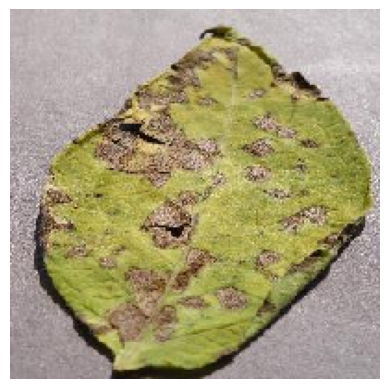

Prediction: Potato___Early_blight


In [51]:
from skimage import io
from keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Load image
img_path = '/content/plantdisease/PlantVillage/Potato___Early_blight/042135e2-e126-4900-9212-d42d900b8125___RS_Early.B 8791.JPG'
img = image.load_img(img_path, color_mode='rgb', target_size=(64, 64))
show_img = image.load_img(img_path, color_mode='rgb', target_size=(200, 200))

# Class list
disease_class = [
    'Pepper__bell___Bacterial_spot','Pepper__bell___healthy','Potato___Early_blight',
    'Potato___Late_blight','Potato___healthy','Tomato_Bacterial_spot','Tomato_Early_blight',
    'Tomato_Late_blight','Tomato_Leaf_Mold','Tomato_Septoria_leaf_spot',
    'Tomato_Spider_mites_Two_spotted_spider_mite','Tomato__Target_Spot',
    'Tomato__Tomato_YellowLeaf__Curl_Virus','Tomato__Tomato_mosaic_virus','Tomato_healthy'
]

# Preprocess image
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x /= 255.0

# Prediction
custom = model.predict(x)
print("Raw Prediction:", custom[0])

# Display image
plt.imshow(show_img)
plt.axis('off')
plt.show()

# Show prediction label
predicted_index = np.argmax(custom[0])
print('Prediction:', disease_class[predicted_index])


In [53]:
model.save('plant_disease_model.h5')

In [54]:
from keras.models import load_model

model = load_model('plant_disease_model.h5')

# Production Version (Flask Web App) : [Plant Disease Diagnosis](https://github.com/shawon100/Plant-Disease-Diagnosis-Flask)

In [55]:
from google.colab import files
files.download('/content/plant_disease_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>